In [24]:
import numpy as np
import odl

1473.8


In [18]:

# Charlotte's money
x = 1473.80

print(x)
# Julian's money
y = 449.24 +3586.14

print(y)
# Factor of Charlotte's money to Julian's money
z = y/x

print(z)    

a = x * z

print(a)

1473.8
4035.38
2.73807843669426
4035.3800000000006


### Definition of the geometry

In [25]:
# Define the reconstruction space (volume of the compressed breast)
# Dimensions are estimated based on typical breast tomosynthesis (in mm)
reco_space = odl.uniform_discr(
    min_pt=[-120, -150, 0],
    max_pt=[120, 150, 60],
    shape=[400, 500, 100],
    dtype='float32'
)

# Limited Angle partition: 25 views from -25 degrees to +25 degrees

angle_min = np.radians(-25)
angle_max = np.radians(25)   
num_views = 25
angle_partition = odl.uniform_partition(angle_min, angle_max, num_views)

# Full Angle partition: 360 views over 360 degrees for the Ground Truth
full_angle_partition = odl.uniform_partition(0, 2 * np.pi, 360)

# Detector partition: 2816 x 3584 pixels, 0.085 mm pitch
# Calculate physical dimensions (in mm) from pixel count and pitch
det_width_half = (2816 * 0.085) / 2.0
det_height_half = (3584 * 0.085) / 2.0

detector_partition = odl.uniform_partition(
    [-det_width_half, -det_height_half], 
    [det_width_half, det_height_half], 
    [2816, 3584]
)

# Geometry distances (in mm)
# The pivoting point is 60 mm above the detector surface
det_radius = 60.0 

# Source-to-isocenter length 'l' should be 590 mm 
# (650 mm Source-to-Image Distance: 650 - 60 = 590)
src_radius = 590.0

# Initialize Cone Beam Geometry (Rotation axis Y)
geometry = odl.applications.tomo.ConeBeamGeometry(
    angle_partition, detector_partition, 
    src_radius=src_radius, det_radius=det_radius,
    axis=[0, 1, 0]
)

geometry_full = odl.applications.tomo.ConeBeamGeometry(
    full_angle_partition, detector_partition, 
    src_radius=src_radius, det_radius=det_radius,
    axis=[0, 1, 0]
)

In [26]:
# Create a discrete Shepp-Logan phantom
phantom = odl.core.phantom.shepp_logan(reco_space, True)

### Forward Projection

In [27]:
# Ray transform (= forward projection)
ray_transfo = odl.applications.tomo.RayTransform(reco_space, geometry, impl='astra_cuda')
ray_transfo_full = odl.applications.tomo.RayTransform(reco_space, geometry_full, impl='astra_cuda')


# Have to add noise to the phantom to make it more realistic, Gaussian noise + Poisson noise.
"XXXXXXXXXXXXXXXXXXXXXXXXXXX"

# Create projection data
proj_data = ray_transfo(phantom)           # Limited views (-25 to +25)
proj_data_full = ray_transfo_full(phantom) # Full views (0 to 360)

### Back Projection

In [28]:
# Setup the Filtered Back-Projection (FDK) operator for the limited geometry
# Using a 'Hann' filter to slightly smooth the image, typical in mammography
fbp_operator = odl.applications.tomo.fbp_op(ray_transfo, filter_type='Hann')  # try different filters like 'Ram-Lak', 'Shepp-Logan', 'Cosine', etc.

# Back-projection using ASTRA FDK on GPU
backproj_fdk = fbp_operator(proj_data)

### Visualisation

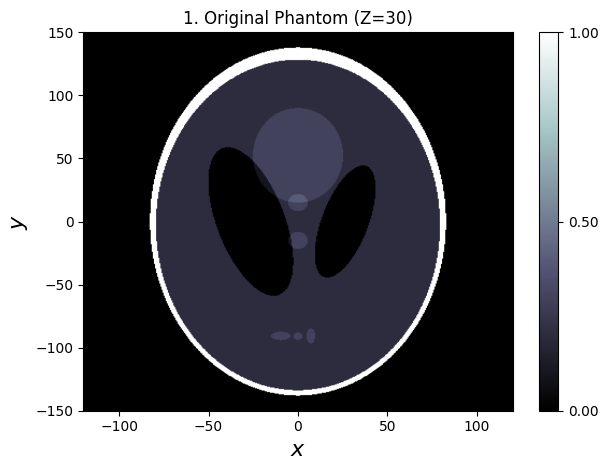

<Figure size 640x480 with 0 Axes>

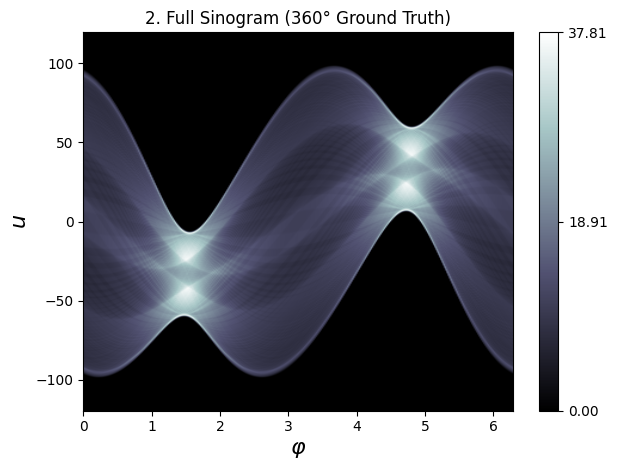

<Figure size 640x480 with 0 Axes>

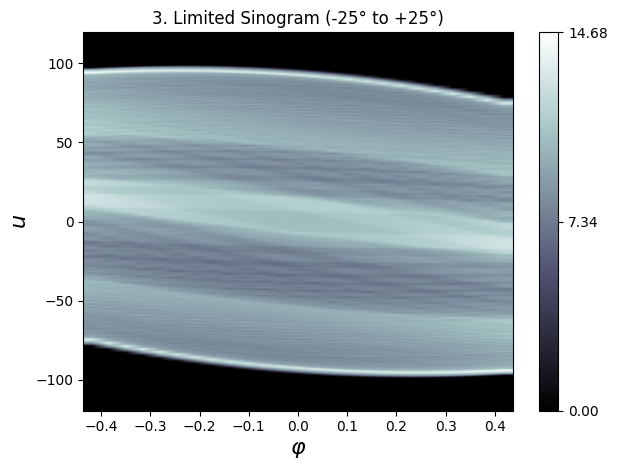

<Figure size 640x480 with 0 Axes>

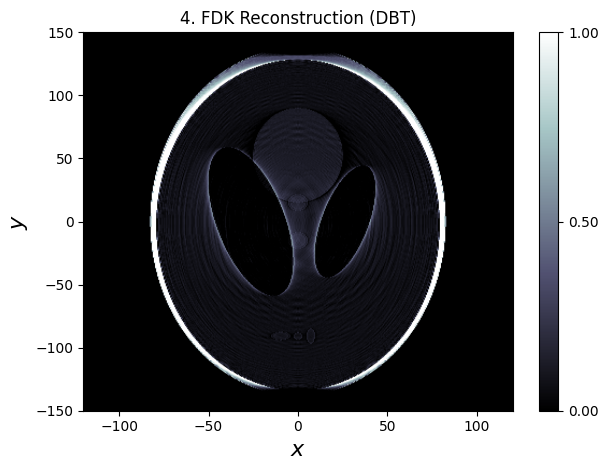

<Figure size 640x480 with 0 Axes>

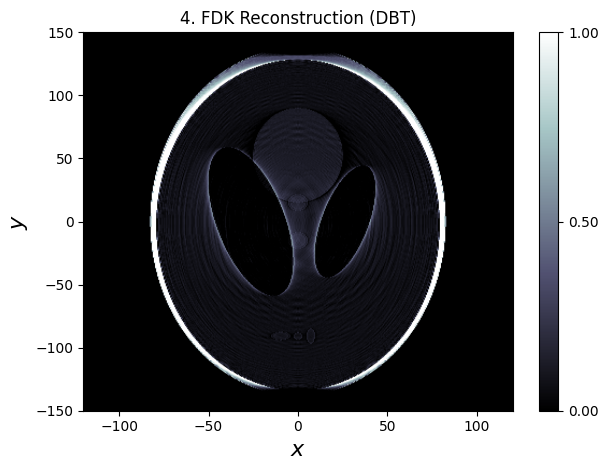

In [29]:
mid_det_y = 0.0  # Middle of the detector in mm (0 mm corresponds to the center of the detector)

# Show original 3D phantom (Slice Z=30)
phantom.show(coords=[None, None, 30], title='1. Original Phantom (Z=30)')

# Show the Full Sinogram (Angle vs Detector X) for the middle Y slice
proj_data_full.show(coords=[None, None, mid_det_y], title='2. Full Sinogram (360° Ground Truth)')

# Show the Limited Sinogram (Angle vs Detector X) for the middle Y slice
proj_data.show(coords=[None, None, mid_det_y], title='3. Limited Sinogram (-25° to +25°)')

# Show FDK Reconstruction (Slice Z=30)
backproj_fdk.show(coords=[None, None, 30], title='4. FDK Reconstruction (DBT)', force_show=True, clim=[0, 1])